# 04 - Validación de Modelos

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, jaccard_score, confusion_matrix

## Cargar dataset y resultados del entrenamiento

In [2]:
df_final = pd.read_csv("../data/processed/customer_features_model.csv", index_col="CustomerID")
df_pred = pd.read_csv("../data/processed/model_predictions.csv", index_col="CustomerID")

df_resultados = df_final.join(df_pred)

print(df_resultados.shape)
df_resultados.head()

(5876, 14)


,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones,Comprador Local,Nomada,label_dbscan,anomalia_dbscan,label_isof,anomalia_isof
CustomerID,,,,,,,,,,,,,,
12347.0,0.497007,0.800347,0.996682,1.095527,-0.242354,-0.074263,0.889322,-0.803925,0,0,-1,1,1,0
12348.0,0.346414,0.299455,1.408970,0.522203,-1.148191,1.162232,-0.411849,-0.803925,0,0,-1,1,1,0
12349.0,1.149578,0.074223,1.094601,1.896758,0.483263,3.418458,0.963390,0.915303,0,0,-1,1,1,0
12350.0,-1.055263,-1.057718,0.312880,0.265187,-0.211304,1.162232,-0.713517,-0.803925,0,0,-1,1,1,0
12351.0,-1.055263,-1.057718,0.616736,0.121669,-0.695665,-0.074263,-0.548894,-0.803925,0,0,-1,1,1,0


In [3]:
cols_perfil = [
    'Permanencia', 'Compras', 'Canasta_Prom', 'Ticket_Prom',
    'Precio_Prom', 'Precio_Max', 'Productos Distintos', 'Pct_Devoluciones'
]

# Silhouette recalculado sobre las etiquetas crudas, igual que en el entrenamiento
sil_score_dbscan = silhouette_score(df_final, df_resultados['label_dbscan'])
sil_score_isof = silhouette_score(df_final, df_resultados['label_isof'])

print("Silhouette Score DBSCAN:", sil_score_dbscan)
print("Silhouette Score Isolation Forest:", sil_score_isof)

Silhouette Score DBSCAN: 0.0805329053409582
Silhouette Score Isolation Forest: 0.5834507706110797


# Evaluación DBSCAN

In [4]:
# Perfil promedio de las variables (escaladas) segun si el cliente fue marcado como anomalia
perfil_dbscan = df_resultados.groupby('anomalia_dbscan')[cols_perfil].mean().round(2)
perfil_dbscan.index = ['Normal (0)', 'Anomalia (1)']
perfil_dbscan

,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
Normal (0),-0.13,-0.20,-0.01,-0.09,-0.12,-0.22,0.01,-0.19
Anomalia (1),0.21,0.31,0.02,0.14,0.18,0.34,-0.02,0.30


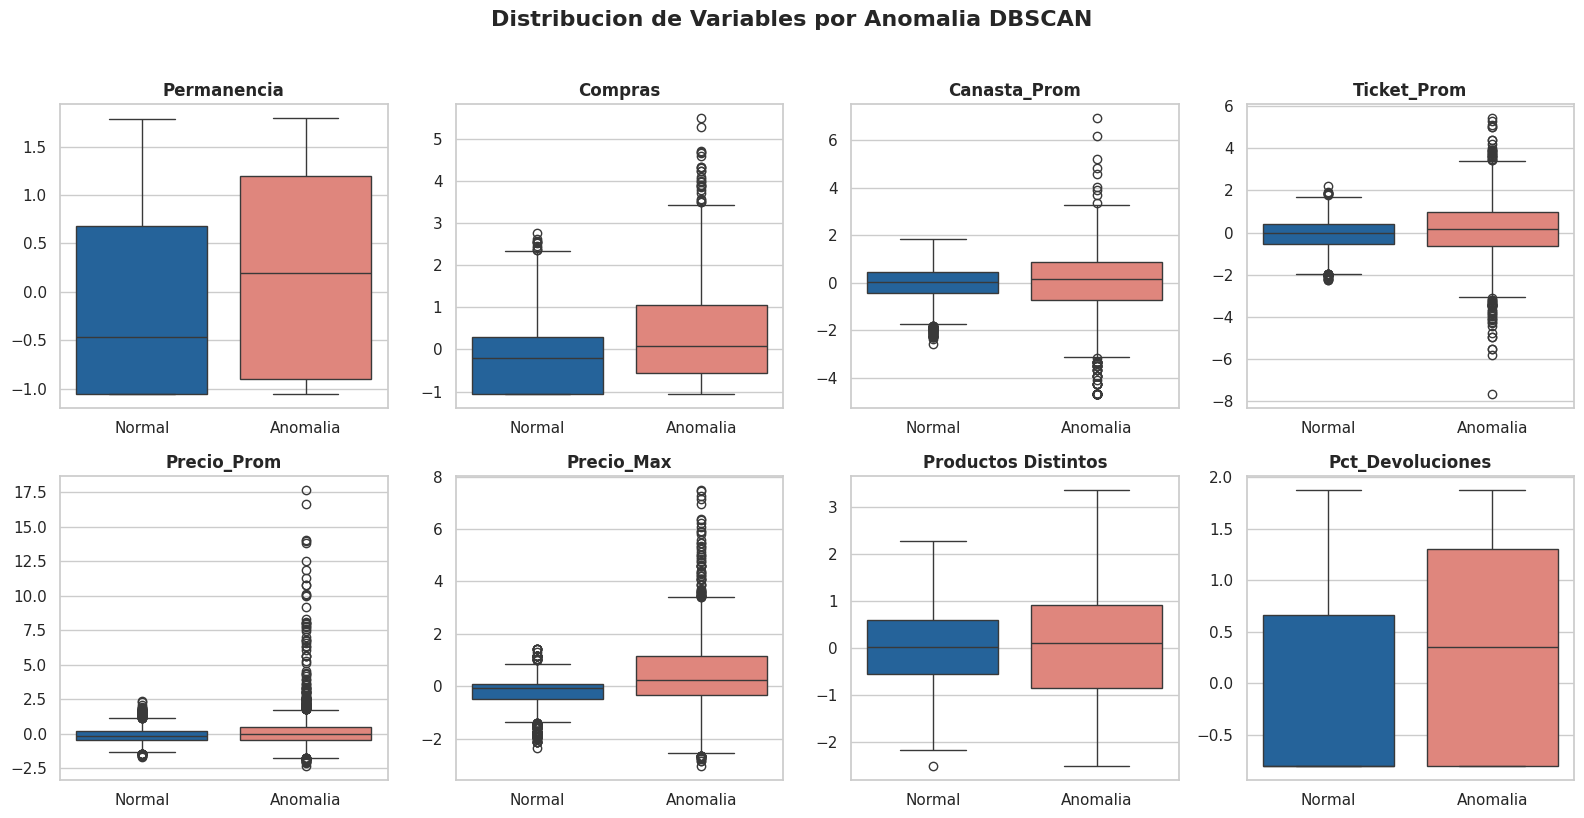

In [5]:
# Boxplots comparando la distribucion de cada variable entre clientes normales y anomalias
n_cols = 4
n_rows = int(np.ceil(len(cols_perfil) / n_cols))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

fig.suptitle(
    'Distribucion de Variables por Anomalia DBSCAN',
    fontsize=16,
    fontweight='bold',
    y=1.02,
)

for ax, col in zip(axes, cols_perfil):
    sns.boxplot(data=df_resultados, x='anomalia_dbscan', y=col, ax=ax, hue='anomalia_dbscan', palette={0: '#1164ad', 1: '#ef796d'}, legend=False)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anomalia'])

for ax in axes[len(cols_perfil):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
sns.reset_defaults()

Varianza explicada por las 2 componentes: 0.6214991901697247


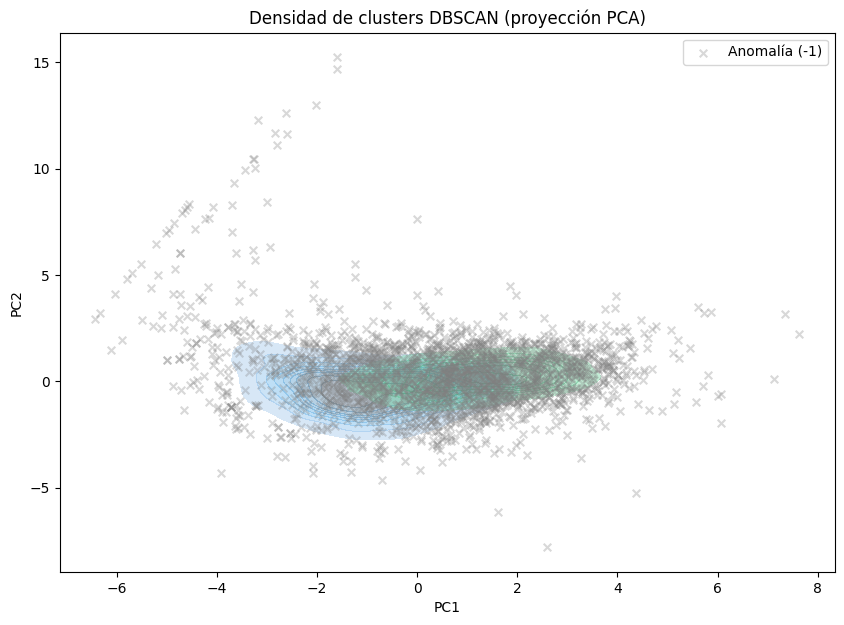

In [6]:
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(df_final)

df_plot = pd.DataFrame(componentes, columns=['PC1', 'PC2'], index=df_final.index)
df_plot['cluster'] = df_resultados['label_dbscan'].values

print("Varianza explicada por las 2 componentes:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 7))

sns.kdeplot(
    data=df_plot[df_plot['cluster'] != -1],
    x='PC1', y='PC2',
    hue='cluster',
    fill=True,
    alpha=0.4,
    palette='viridis'
)

anomalias = df_plot[df_plot['cluster'] == -1]
plt.scatter(anomalias['PC1'], anomalias['PC2'], color='gray', label='Anomalía (-1)', s=30, marker='x', alpha=0.3)

plt.title('Densidad de clusters DBSCAN (proyección PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

**Comentarios:**

* **Silhouette Score :** El score obtenido (~0.08) esta muy cerca de 0, lo cual indica que los clusters formados por DBSCAN se encuentran bastante solapados entre si. Esto es consistente con la naturaleza del dataset, donde no existen grupos de densidad claramente separados sino un continuo de comportamientos de compra.
* **Porcentaje de anomalias :** DBSCAN marco como ruido (anomalia) al 39.06% de los clientes (2,295 de 5,876). Este porcentaje es demasiado alto para considerarse un conjunto de anomalias accionable desde el punto de vista de negocio; mas bien refleja zonas de baja densidad del espacio de variables que DBSCAN no logra asignar a ninguno de los 2 clusters encontrados.
* **Perfil promedio :** Los clientes marcados como anomalia muestran valores ligeramente mas altos en Permanencia, Compras, Ticket_Prom, Precio_Max y Pct_Devoluciones, pero las diferencias respecto a los clientes normales son pequeñas (diferencias de medias menores a 0.35 desviaciones estandar). Esto refuerza que el "ruido" de DBSCAN no corresponde a un grupo de outliers extremos, sino a clientes en zonas de transicion entre clusters.
* **Conclusion :** DBSCAN logra segmentar un cluster mayoritario de clientes con comportamiento tipico, pero su definicion de anomalia (el ruido) es demasiado amplia y poco discriminativa para usarse como deteccion de anomalias por si sola, dado el bajo silhouette score y la debil separacion de perfiles.

# Evaluación Isolation Forest

In [7]:
# Perfil promedio de las variables (escaladas) segun si el cliente fue marcado como anomalia
perfil_isof = df_resultados.groupby('anomalia_isof')[cols_perfil].mean().round(2)
perfil_isof.index = ['Normal (0)', 'Anomalia (1)']
perfil_isof

,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
Normal (0),-0.00,-0.01,0.01,-0.01,-0.05,-0.03,0.01,-0.01
Anomalia (1),0.01,0.54,-0.76,0.91,3.46,2.52,-0.59,0.54


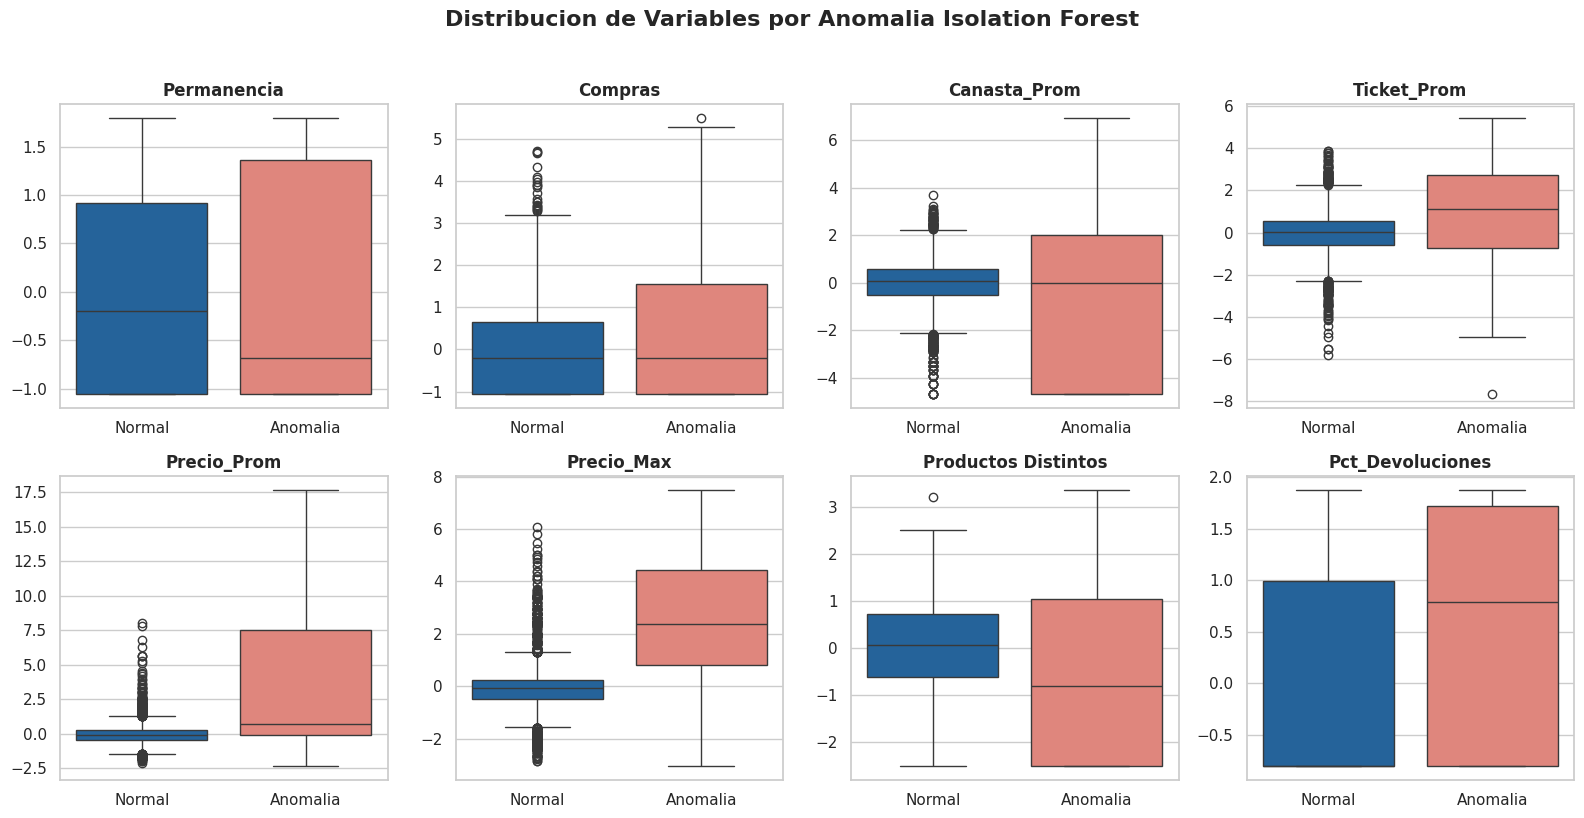

In [8]:
# Boxplots comparando la distribucion de cada variable entre clientes normales y anomalias
n_cols = 4
n_rows = int(np.ceil(len(cols_perfil) / n_cols))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

fig.suptitle(
    'Distribucion de Variables por Anomalia Isolation Forest',
    fontsize=16,
    fontweight='bold',
    y=1.02,
)

for ax, col in zip(axes, cols_perfil):
    sns.boxplot(data=df_resultados, x='anomalia_isof', y=col, ax=ax, hue='anomalia_isof', palette={0: '#1164ad', 1: '#ef796d'}, legend=False)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anomalia'])

for ax in axes[len(cols_perfil):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
sns.reset_defaults()

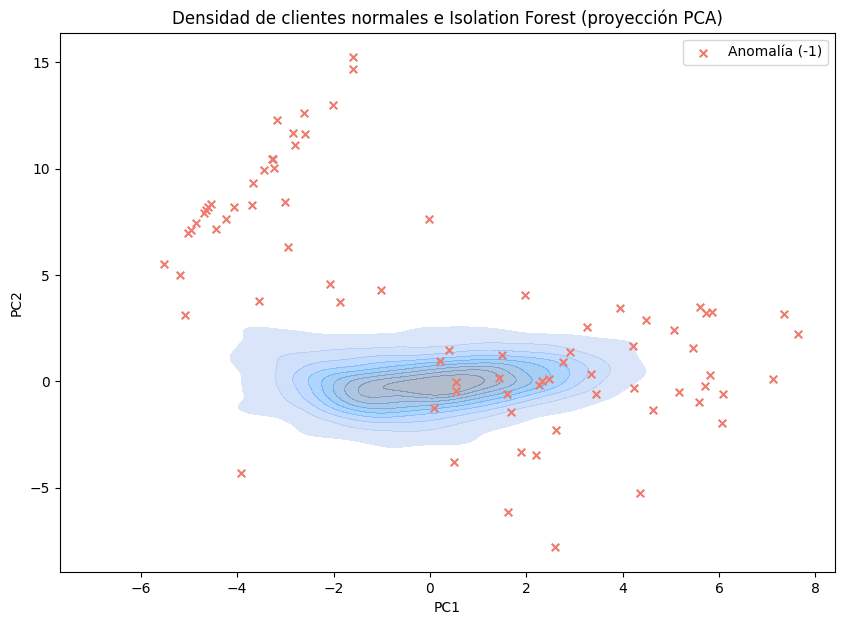

In [9]:
# Reutilizamos la proyeccion PCA calculada para DBSCAN (mismo df_final, mismas 2 componentes)
df_plot_isof = pd.DataFrame(componentes, columns=['PC1', 'PC2'], index=df_final.index)
df_plot_isof['cluster'] = df_resultados['label_isof'].values

plt.figure(figsize=(10, 7))

sns.kdeplot(
    data=df_plot_isof[df_plot_isof['cluster'] != -1],
    x='PC1', y='PC2',
    fill=True,
    alpha=0.4,
    color='#1164ad',
)

anomalias_isof = df_plot_isof[df_plot_isof['cluster'] == -1]
plt.scatter(anomalias_isof['PC1'], anomalias_isof['PC2'], color='#ef796d', label='Anomalía (-1)', s=30, marker='x')

plt.title('Densidad de clientes normales e Isolation Forest (proyección PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

**Comentarios:**

* **Silhouette Score :** El score obtenido (~0.58) es considerablemente mas alto que el de DBSCAN (~0.08), lo cual indica que el grupo de anomalias identificado por Isolation Forest esta mucho mejor separado del resto de los clientes.
* **Porcentaje de anomalias :** Isolation Forest marco unicamente al 1.34% de los clientes (79 de 5,876) como anomalia, un porcentaje mucho mas razonable y accionable para el negocio que el 39.06% de DBSCAN.
* **Perfil promedio :** A diferencia de DBSCAN, los clientes anomalos de Isolation Forest muestran diferencias marcadas frente a los normales, sobre todo en Precio_Prom (+3.46 desviaciones estandar) y Precio_Max (+2.52), ademas de Ticket_Prom (+0.91) y Pct_Devoluciones (+0.54). Esto describe un grupo de clientes que compran productos considerablemente mas caros de lo usual y/o que tienen tasas de devolucion elevadas, un patron mucho mas claro y accionable que el de DBSCAN.
* **Conclusion :** Isolation Forest logra aislar un grupo pequeño y bien diferenciado de clientes atipicos, en lugar de simplemente etiquetar como ruido a los clientes en zonas de baja densidad. Esto lo hace mas adecuado que DBSCAN para la tarea especifica de deteccion de anomalias sobre este conjunto de datos.

# Comparación de Evaluación

In [10]:
# Tabla resumen comparando ambos modelos de deteccion de anomalias
resumen_comparacion = pd.DataFrame({
    'Silhouette Score' : [sil_score_dbscan, sil_score_isof],
    'Anomalias Detectadas' : [df_resultados['anomalia_dbscan'].sum(), df_resultados['anomalia_isof'].sum()],
    'Porcentaje Anomalias' : [df_resultados['anomalia_dbscan'].mean() * 100, df_resultados['anomalia_isof'].mean() * 100],
}, index=['DBSCAN', 'Isolation Forest']).round(2)

resumen_comparacion

,Silhouette Score,Anomalias Detectadas,Porcentaje Anomalias
DBSCAN,0.08,2295,39.06
Isolation Forest,0.58,79,1.34


In [11]:
# Cuantos clientes fueron marcados como anomalia por ambos modelos, solo uno, o ninguno
tabla_cruzada = pd.crosstab(
    df_resultados['anomalia_dbscan'].map({0: 'Normal', 1: 'Anomalia'}),
    df_resultados['anomalia_isof'].map({0: 'Normal', 1: 'Anomalia'}),
    rownames=['DBSCAN'],
    colnames=['Isolation Forest'],
)
tabla_cruzada

Isolation Forest,Anomalia,Normal
DBSCAN,,
Anomalia,79,2216
Normal,0,3581


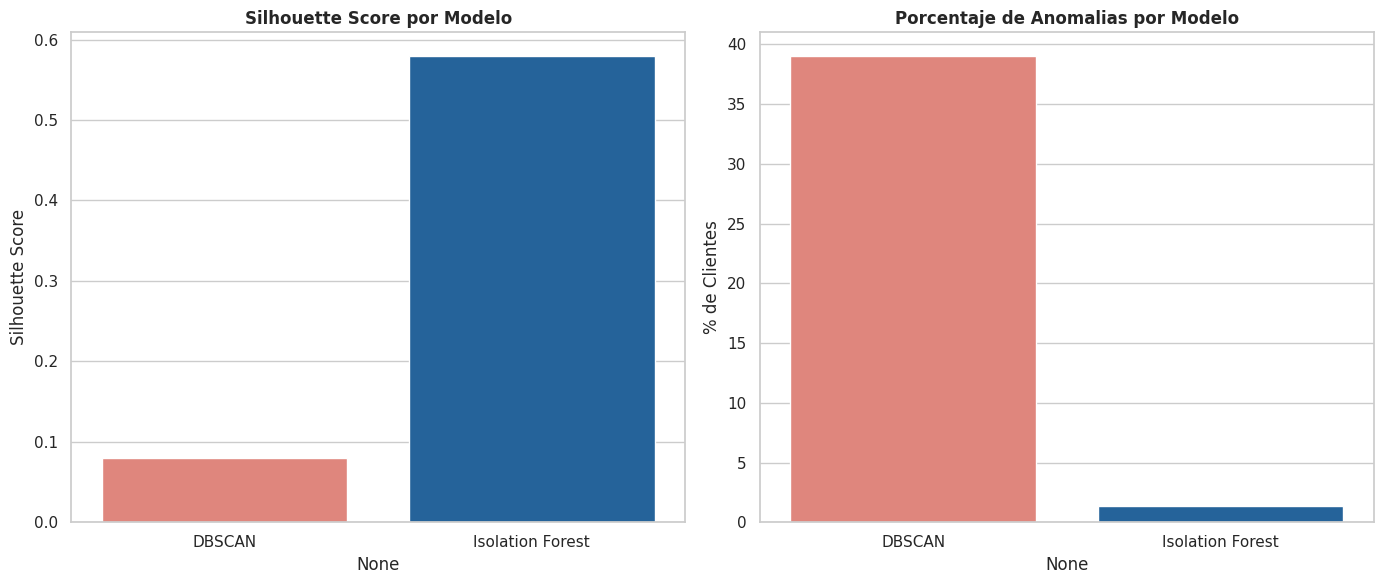

In [12]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x=resumen_comparacion.index,
    y=resumen_comparacion['Silhouette Score'],
    hue=resumen_comparacion.index,
    palette={'DBSCAN': '#ef796d', 'Isolation Forest': '#1164ad'},
    legend=False,
    ax=axes[0],
)
axes[0].set_title('Silhouette Score por Modelo', fontweight='bold')
axes[0].set_ylabel('Silhouette Score')

sns.barplot(
    x=resumen_comparacion.index,
    y=resumen_comparacion['Porcentaje Anomalias'],
    hue=resumen_comparacion.index,
    palette={'DBSCAN': '#ef796d', 'Isolation Forest': '#1164ad'},
    legend=False,
    ax=axes[1],
)
axes[1].set_title('Porcentaje de Anomalias por Modelo', fontweight='bold')
axes[1].set_ylabel('% de Clientes')

plt.tight_layout()
plt.show()
sns.reset_defaults()

**Comentarios:**

* **Silhouette Score :** Isolation Forest (~0.58) supera ampliamente a DBSCAN (~0.08). El grupo de anomalias de Isolation Forest esta mucho mejor definido y separado del resto de los clientes.
* **Porcentaje de anomalias :** DBSCAN marca al 39.06% de los clientes como ruido, mientras que Isolation Forest marca solo al 1.34%. Un porcentaje tan alto como el de DBSCAN es poco util para el negocio, ya que no permite priorizar acciones sobre un grupo reducido y manejable de clientes.
* **Coincidencia entre modelos :** La tabla cruzada muestra que las 79 anomalias detectadas por Isolation Forest son un subconjunto de los clientes que DBSCAN ya marcaba como ruido (ningun cliente clasificado como normal por DBSCAN fue marcado como anomalia por Isolation Forest). Esto sugiere que Isolation Forest logra aislar, dentro del amplio grupo de ruido de DBSCAN, a los casos verdaderamente extremos.
* **Conclusion final :** Para esta tarea de deteccion de anomalias en clientes, Isolation Forest es el modelo mas adecuado: obtiene un silhouette score mucho mayor, identifica un porcentaje de anomalias mas razonable y accionable, y su perfil de anomalias (precios promedio y maximos elevados, alta tasa de devoluciones) es mucho mas interpretable desde el punto de vista de negocio. DBSCAN resulta mas util como herramienta de segmentacion general (encontro un cluster mayoritario coherente), pero no como detector de anomalias por si solo, dado que su nocion de "ruido" es demasiado amplia y poco discriminativa.